# Comparison of DL Models for **Arrhythmia Heartbeat Detection**
### _for MIT-BIH Arrhythmia Database_

---
### Phase A - Setup and Prepreparation
---
* Fixing random seeds
* importing the libraries used throughout 
* printing a reproducibility record (library versions + hardware)

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import sklearn as skl
import imblearn

import wfdb
import shap

SEED = 88

# Set global seeds
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#if running on GPUs (not in google colab)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except (AttributeError, RuntimeError):
    pass

print("\n--- REPRODUCIBILITY RECORD ---")
print(f"Python version:          {sys.version.split()[0]}")
print(f"NumPy version:           {np.__version__}")
print(f"Pandas version:          {pd.__version__}")
print(f"PyTorch version:         {torch.__version__}")
print(f"Scikit-Learn version:    {skl.__version__}")
print(f"Imblearn version:        {imblearn.__version__}")
print(f"WFDB version:            {wfdb.__version__}")
print(f"SHAP version:            {shap.__version__}")
print(f"CUDA Available:          {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device:          {torch.cuda.get_device_name(0)}")
print("------------------------------")


--- REPRODUCIBILITY RECORD ---
Python version:          3.12.10
NumPy version:           1.26.4
Pandas version:          2.2.2
PyTorch version:         2.3.0+cpu
Scikit-Learn version:    1.4.2
Imblearn version:        0.12.2
WFDB version:            4.1.2
SHAP version:            0.45.1
CUDA Available:          False
------------------------------


---
### Phase B - Data Loading and Exploratory Visualization
---
Loads a single MIT-BIH record (**100**) via `wfdb.rdrecord()` / `wfdb.rdann()` from Local secondry memory
* Printing inital 5 records of the dataset
* Visualizations used here:
    1. **Raw waveform**
    2. **Annotated waveform**
    3. **Dual-lead comparison**
    4. **RR-interval scatter plot**
* Importing dataset using rdrecord()

In [35]:
import pandas as pd
from IPython.display import display, HTML


record = wfdb.rdrecord('./dataset/100')
annotation = wfdb.rdann('./dataset/100', 'atr')

df = pd.DataFrame(record.p_signal[:5], columns=record.sig_name)
dfa = pd.DataFrame({'sample': annotation.sample, 'symbol': annotation.symbol})
html_str = f"""
<div style="display: flex; gap: 70px;">
    <div>
        {df.head().to_html()}
    </div>
    <div>
        {dfa.head().to_html()}
    </div>
</div>
"""

# Render the side-by-side HTML
display(HTML(html_str))

,MLII,V5
0,-0.145,-0.065
1,-0.145,-0.065
2,-0.145,-0.065
3,-0.145,-0.065
4,-0.145,-0.065
,sample,symbol
0,18,+
1,77,N
2,370,N
3,662,N


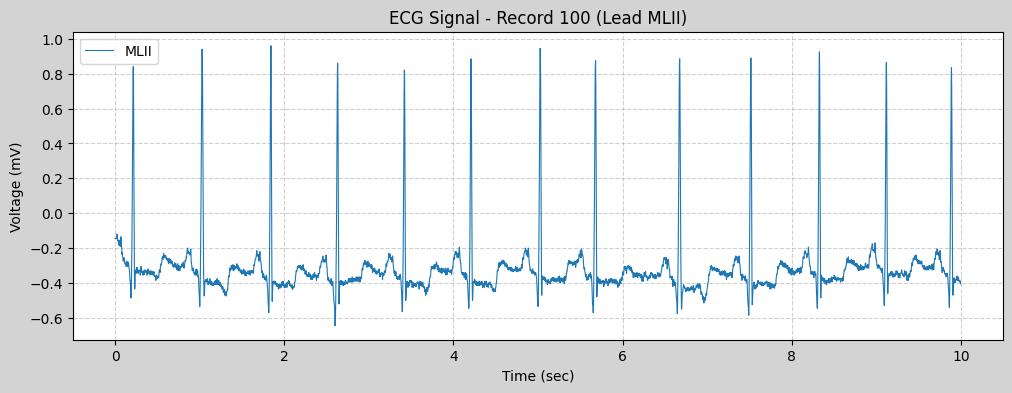

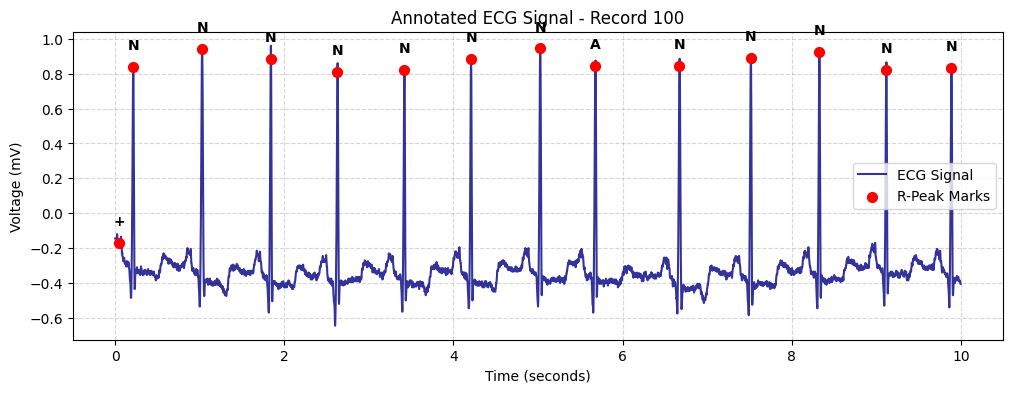

In [36]:
fs=record.fs
num_samples=fs*10

time_axis = np.arange(num_samples) / fs
signal_ch0 = record.p_signal[:num_samples, 0]

plt.figure(figsize=(12, 4),facecolor='lightgrey')
plt.plot(time_axis, signal_ch0, linewidth=0.8, label=record.sig_name[0])
plt.title(f"ECG Signal - Record {record.record_name} (Lead {record.sig_name[0]})")
plt.xlabel("Time (sec)")
plt.ylabel("Voltage (mV)")
plt.grid(linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.show()


# Get annotations within the first 10 seconds (sample < 3600)
mask = annotation.sample < num_samples
peak_samples = annotation.sample[mask]
peak_symbols = np.array(annotation.symbol)[mask]

# Convert peak sample indices to time & voltage values
peak_times = peak_samples / fs
peak_voltages = record.p_signal[peak_samples, 0]

# Plot continuous signal
plt.figure(figsize=(12, 4))
plt.plot(time_axis, signal_ch0, color='navy', label='ECG Signal', alpha=0.8)

# Overlay Scatter Plot for Annotations
plt.scatter(peak_times, peak_voltages, color='red', s=50, zorder=5, label='R-Peak Marks')

# Annotate each scatter point with its Cardiologist Symbol ('N', etc.)
for t, v, symbol in zip(peak_times, peak_voltages, peak_symbols):
    plt.text(t, v + 0.1, symbol, fontsize=10, fontweight='bold', ha='center')

plt.title(f"Annotated ECG Signal - Record {record.record_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# # Channel 0 (MLII)
# axes[0].plot(time_axis, record.p_signal[:num_samples, 0], color='blue')
# axes[0].set_ylabel(f"{record.sig_name[0]} (mV)")
# axes[0].grid(True, linestyle='--')

# # Channel 1 (V1)
# axes[1].plot(time_axis, record.p_signal[:num_samples, 1], color='green')
# axes[1].set_ylabel(f"{record.sig_name[1]} (mV)")
# axes[1].set_xlabel("Time (seconds)")
# axes[1].grid(True, linestyle='--')

# plt.suptitle(f"Dual-Lead ECG Comparison - Record {record.record_name}")
# plt.show()

# # Compute RR-intervals (differences between consecutive peak samples in milliseconds)
# rr_intervals = np.diff(annotation.sample) / fs * 1000  # in ms

# rr_n = rr_intervals[:-1]    # RR_n
# rr_n_plus_1 = rr_intervals[1:] # RR_{n+1}

# plt.figure(figsize=(6, 6))
# plt.scatter(rr_n, rr_n_plus_1, color='purple', alpha=0.5, s=15)
# plt.plot([200, 1200], [200, 1200], color='gray', linestyle='--')  # Identity line x=y
# plt.title(f"Poincaré Scatter Plot (RR_n vs RR_n+1) - Record {record.record_name}")
# plt.xlabel("RR_n (ms)")
# plt.ylabel("RR_n+1 (ms)")
# plt.grid(True)
# plt.show()